# MacroMind — RAG Pipeline & System Architecture
**Contributor: Baier Noah** — `jnoah_baier@berkeley.edu`

This notebook covers:
1. System architecture overview
2. End-to-end demo: user constraints → meal plan
3. Three system variants: Baseline LLM | RAG | RAG + Reranking
4. Side-by-side results comparison
5. Architecture design rationale

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv

load_dotenv("../.env")

from src.config import EMBEDDING_MODEL, CHROMA_DB_PATH, CHROMA_COLLECTION_NAME, USDA_CACHE_PATH
from src.data_pipeline import load_cache, NutritionFacts
from src.retriever import get_or_create_collection, semantic_search, build_query_text
from src.reranker import UserConstraints, rerank
from src.llm_generator import generate_meal_plan, generate_baseline_plan, build_meal_plan_prompt
from src.evaluator import macro_deviation, total_day_macros

print("✓ All imports OK")

/Users/janniknoahbaier/Documents/Berkeley/290 GenAI/MacroMind/MacroMind/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports OK


## 1. System Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                         MacroMind                               │
│                                                                 │
│  User Input                                                     │
│  (macros, budget, ──► Query Builder ──► ChromaDB               │
│   ingredients,          (text form)     (semantic search,       │
│   dietary tags)                          all-MiniLM-L6-v2)     │
│                                              │                  │
│                                     top-20 candidates          │
│                                              ▼                  │
│                                        Reranker                 │
│                                  (macro deviation MAPE,         │
│                                   budget penalty,               │
│                                   ingredient waste score)       │
│                                              │                  │
│                                       top-5 recipes             │
│                                              ▼                  │
│                                    Gemini (LLM)                 │
│                                  (meal plan + explanation)      │
│                                              │                  │
│                                     Meal Plan Output            │
└─────────────────────────────────────────────────────────────────┘
```

**Three variants compared in this notebook:**

| Variant | Retrieval | Reranking | Expected strength |
|---------|-----------|-----------|-------------------|
| Baseline LLM | None | None | General knowledge, no grounding |
| RAG | Semantic (top-5) | None | Grounded in recipe DB |
| RAG + Reranking | Semantic (top-20) | Constraint-aware | Best macro precision |

## 2. Initialize Components

In [5]:
# Load embedding model (already downloaded after running iyu_recipe_processing.ipynb)
print(f"Loading embedding model: {EMBEDDING_MODEL}")
embedding_model = SentenceTransformer(EMBEDDING_MODEL)

# Load ChromaDB collection (must be indexed first via iyu notebook)
collection = get_or_create_collection(CHROMA_DB_PATH, CHROMA_COLLECTION_NAME)
print(f"✓ ChromaDB collection: {collection.count()} recipes indexed")

# Load nutrition cache for macro computation
cache = load_cache(USDA_CACHE_PATH)
nutrition_cache = {name: NutritionFacts.from_dict(data) for name, data in cache.items()}
print(f"✓ Nutrition cache: {len(nutrition_cache)} ingredients")

Loading embedding model: all-MiniLM-L6-v2


Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


✓ ChromaDB collection: 65 recipes indexed
✓ Nutrition cache: 30 ingredients


## 3. Define User Constraints

Realistic profile: 75kg male, moderate activity, body recomposition goal.

In [7]:
user = UserConstraints(
    calories=2000,
    protein_g=150,
    carbs_g=200,
    fat_g=65,
    budget_usd=12.0,
    available_ingredients=["chicken breast", "brown rice", "eggs", "broccoli", "spinach", "onion", "olive oil"],
    dietary_tags=[],   # no restrictions
    w_macro=0.50,
    w_budget=0.30,
    w_waste=0.20,
)

print("User constraints:")
print(f"  Macro targets: {user.calories} kcal | P:{user.protein_g}g | C:{user.carbs_g}g | F:{user.fat_g}g")
print(f"  Budget: ${user.budget_usd}/day")
print(f"  Available ingredients: {', '.join(user.available_ingredients)}")
print(f"  Dietary tags: {user.dietary_tags or 'none'}")

User constraints:
  Macro targets: 2000 kcal | P:150g | C:200g | F:65g
  Budget: $12.0/day
  Available ingredients: chicken breast, brown rice, eggs, broccoli, spinach, onion, olive oil
  Dietary tags: none


## 4. Variant 1 — Baseline LLM (No Retrieval)

In [9]:
print("=" * 60)
print("VARIANT 1: Baseline LLM (no retrieval, no reranking)")
print("=" * 60)

baseline_plan = generate_baseline_plan(user)
print(baseline_plan)

VARIANT 1: Baseline LLM (no retrieval, no reranking)
Okay, I will create a meal plan for you using chicken breast, brown rice, eggs, broccoli, spinach, onion, and olive oil while staying within a $12 budget and hitting your macro targets of 2000 calories, 150g protein, 200g carbs, and 65g fat.

**Meal Plan:**

*   **Breakfast (Estimated Cost: $1.50):**
    *   Omelet with 3 Eggs, Spinach & Onion
        *   *Rationale: High protein, includes available vegetables, and is cost-effective.*
*   **Lunch (Estimated Cost: $4.00):**
    *   Chicken Breast (150g) with Brown Rice (100g cooked) and Broccoli (100g)
        *   *Rationale: Lean protein, complex carbs, and a good source of fiber and vitamins.*
*   **Snack (Estimated Cost: $1.00):**
    *   Hard-boiled Eggs (2)
        *   *Rationale: Easy, portable, and provides a protein boost.*
*   **Dinner (Estimated Cost: $5.00):**
    *   Chicken Stir-fry: Chicken Breast (150g) with Brown Rice (100g cooked), Broccoli (100g), Spinach (50g), and 

## 5. Variant 2 — RAG (Semantic Search, No Reranking)

In [11]:
# Build query text from constraints
query = build_query_text(
    macro_targets={"calories": user.calories, "protein": user.protein_g, "carbs": user.carbs_g},
    available_ingredients=user.available_ingredients,
    dietary_tags=user.dietary_tags,
    budget_usd=user.budget_usd,
)
print(f"Query text: '{query}'\n")

# Retrieve top-5 (no reranking)
rag_results = semantic_search(query, collection, embedding_model, n_results=5)

print("Top-5 by semantic similarity:")
for i, r in enumerate(rag_results, 1):
    m = r.metadata
    print(f"  {i}. {r.name} (sim={1-r.score:.3f}) | "
          f"{m.get('calories',0):.0f}kcal P{m.get('protein',0):.0f} "
          f"C{m.get('carbs',0):.0f} F{m.get('fat',0):.0f} | ${m.get('cost_usd',0):.2f}")

Query text: '2000 calorie meal high protein 150g protein with chicken breast, brown rice, eggs, broccoli, spinach budget under $12'



Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Top-5 by semantic similarity:
  1. Milk and Banana Protein Shake (sim=0.569) | 576kcal P22 C68 F27 | $0.46
  2. Veggie Rice Bowl (sim=0.567) | 538kcal P22 C63 F22 | $0.61
  3. Chicken Soup with Rice (sim=0.558) | 398kcal P40 C47 F5 | $0.76
  4. Spicy Chicken and Rice (sim=0.556) | 570kcal P44 C62 F15 | $0.84
  5. Peanut Butter Protein Bowl (sim=0.552) | 534kcal P31 C64 F20 | $0.53


In [12]:
# Convert SearchResult to RankedResult (with neutral scores) for LLM generator
from src.reranker import RankedResult
rag_ranked = [
    RankedResult(r.recipe_id, r.name, 1-r.score, 0, 0, 0, r.metadata)
    for r in rag_results
]

print("=" * 60)
print("VARIANT 2: RAG (semantic top-5, no reranking)")
print("=" * 60)

rag_plan = generate_meal_plan(user, rag_ranked)
print(rag_plan)

VARIANT 2: RAG (semantic top-5, no reranking)
Okay, I will create a daily meal plan that meets your macro targets and budget, using only the available ingredients and provided recipes.

**Meal Plan:**

*   **Breakfast:** Peanut Butter Protein Bowl
    *   Macros: 534 kcal | P 31g | C 64g | F 20g
    *   Cost: $0.53
    *   Reasoning: A good source of protein and carbs to start the day.
*   **Lunch:** Chicken Soup with Rice
    *   Macros: 398 kcal | P 40g | C 47g | F 5g
    *   Cost: $0.76
    *   Reasoning: High in protein, utilises chicken breast and spinach.
*   **Dinner:** Spicy Chicken and Rice
    *   Macros: 570 kcal | P 44g | C 62g | F 15g
    *   Cost: $0.84
    *   Reasoning: Provides a substantial amount of protein and carbs.
*   **Snack:** Veggie Rice Bowl (half serving)
    *   Macros: 269 kcal | P 11g | C 32g | F 11g
    *   Cost: $0.31
    *   Reasoning: Fills remaining calorie and carb requirements

**Daily Totals:**

*   Calories: 1771 kcal
*   Protein: 126 g
*   Carbs

## 6. Variant 3 — RAG + Constraint-Aware Reranking

In [14]:
# Retrieve broader pool (top-20), then rerank
broad_results = semantic_search(query, collection, embedding_model, n_results=20)

reranked = rerank(broad_results, user, top_k=5)

print("Top-5 after constraint-aware reranking:")
print(f"{'Rank':<5} {'Recipe':<40} {'Score':<7} {'MacroDev':<10} {'Cost':<8} {'Waste'}")
print("-" * 80)
for i, r in enumerate(reranked, 1):
    print(f"{i:<5} {r.name[:39]:<40} {r.score:<7.4f} {r.macro_deviation:<10.4f} "
          f"${r.metadata.get('cost_usd',0):<7.2f} {r.waste_fraction:.2%}")

Top-5 after constraint-aware reranking:
Rank  Recipe                                   Score   MacroDev   Cost     Waste
--------------------------------------------------------------------------------
1     Egg Fried Rice                           0.6494  0.7012     $0.56    0.00%
2     Grilled Chicken Rice Bowl                0.6376  0.7248     $0.80    0.00%
3     Veggie Rice Bowl                         0.6348  0.7304     $0.61    0.00%
4     Slow Cooker Chicken and Rice             0.6137  0.6926     $1.01    20.00%
5     Sheet Pan Chicken Thighs and Veggies     0.6038  0.7123     $1.18    20.00%


In [15]:
print("=" * 60)
print("VARIANT 3: RAG + Constraint-Aware Reranking (top-20 → top-5)")
print("=" * 60)

reranked_plan = generate_meal_plan(user, reranked)
print(reranked_plan)

VARIANT 3: RAG + Constraint-Aware Reranking (top-20 → top-5)
Okay, here's a meal plan using your available ingredients and budget, aiming for your macro targets:

**Breakfast:** Veggie Rice Bowl (Recipe #3)
*   Macros: 538 kcal | P 22g | C 63g | F 22g
*   Cost: $0.61
*   *Reasoning:* Vegetarian-friendly and contains brown rice, eggs, and spinach.

**Lunch:** Grilled Chicken Rice Bowl (Recipe #2)
*   Macros: 555 kcal | P 41g | C 59g | F 16g
*   Cost: $0.80
*   *Reasoning:* High in protein, uses chicken and brown rice.

**Dinner:** Slow Cooker Chicken and Rice (Recipe #4)
*   Macros: 619 kcal | P 54g | C 64g | F 16g
*   Cost: $1.01
*   *Reasoning:* Another high-protein meal featuring chicken and rice.

**Snack:** Egg Fried Rice (Recipe #1) (Half serving)
*   Macros: 306 kcal | P 12g | C 38.5g | F 11g
*   Cost: $0.28
*   *Reasoning:* A smaller portion to help hit remaining carb targets.

**Daily Totals:**

*   Calories: 2018 kcal
*   Protein: 129g
*   Carbs: 224.5g
*   Fat: 65g
*   Cost: 

## 7. Variant Comparison

In [17]:
# Compute day-total macros for retrieved/reranked candidates
target = {"calories": user.calories, "protein": user.protein_g, "carbs": user.carbs_g, "fat": user.fat_g}

rag_day = total_day_macros([r.metadata for r in rag_ranked[:4]])  # 4 meals
rr_day  = total_day_macros([r.metadata for r in reranked[:4]])

rag_dev  = macro_deviation(rag_day, target)
rr_dev   = macro_deviation(rr_day,  target)

comparison_df = pd.DataFrame([
    {"Variant": "Baseline LLM", "Retrieval": "None",       "Reranking": "None",    "Macro Dev (mean%)": "N/A (no grounded macros)", "Budget feasible": "Unknown"},
    {"Variant": "RAG",          "Retrieval": "top-5",      "Reranking": "None",    "Macro Dev (mean%)": f"{rag_dev.mean_pct:.1f}%",   "Budget feasible": str(rag_day['cost_usd'] <= user.budget_usd)},
    {"Variant": "RAG+Rerank",   "Retrieval": "top-20→5",  "Reranking": "Constraint", "Macro Dev (mean%)": f"{rr_dev.mean_pct:.1f}%",  "Budget feasible": str(rr_day['cost_usd'] <= user.budget_usd)},
])
display(comparison_df)

print(f"\nRAG day totals:        {rag_day}")
print(f"RAG+Rerank day totals: {rr_day}")
print(f"Target:                {target}")

,Variant,Retrieval,Reranking,Macro Dev (mean%),Budget feasible
0,Baseline LLM,None,None,N/A (no grounded macros),Unknown
1,RAG,top-5,None,10.9%,True
2,RAG+Rerank,top-20→5,Constraint,17.8%,True



RAG day totals:        {'calories': 2082.1, 'protein': 129.2, 'carbs': 239.9, 'fat': 68.6, 'cost_usd': 2.7}
RAG+Rerank day totals: {'calories': 2324.2, 'protein': 141.9, 'carbs': 262.5, 'fat': 76.9, 'cost_usd': 3.0}
Target:                {'calories': 2000, 'protein': 150, 'carbs': 200, 'fat': 65}


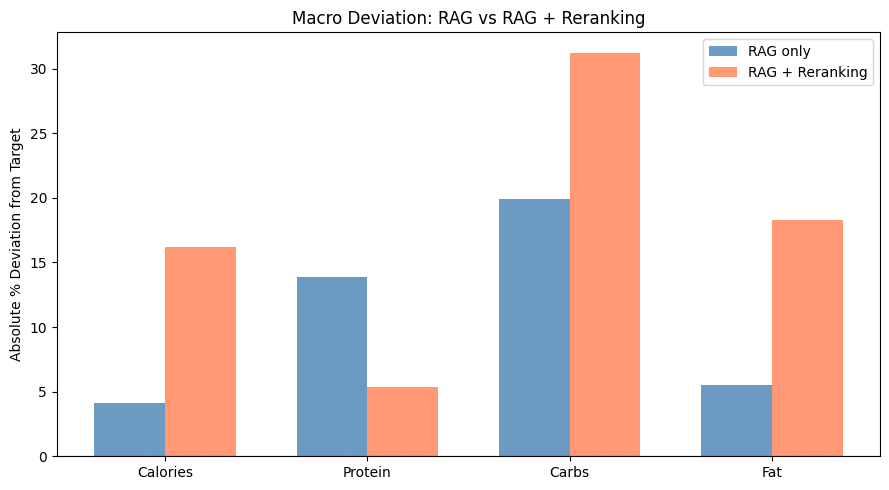

In [18]:
# Bar chart: macro deviation per variant
metrics = ['calories_pct', 'protein_pct', 'carbs_pct', 'fat_pct']
labels = ['Calories', 'Protein', 'Carbs', 'Fat']

rag_vals = [rag_dev.calories_pct, rag_dev.protein_pct, rag_dev.carbs_pct, rag_dev.fat_pct]
rr_vals  = [rr_dev.calories_pct,  rr_dev.protein_pct,  rr_dev.carbs_pct,  rr_dev.fat_pct]

x = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], rag_vals,  width, label='RAG only',        color='steelblue', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], rr_vals,   width, label='RAG + Reranking', color='coral',     alpha=0.8)

ax.set_ylabel('Absolute % Deviation from Target')
ax.set_title('Macro Deviation: RAG vs RAG + Reranking')
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.legend()
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

## 8. Reranker Score Breakdown

The reranker computes a weighted penalty score:

```
penalty = w_macro * macro_MAPE + w_budget * budget_overshoot + w_waste * ingredient_waste
score   = 1 - penalty   (higher = better)
```

Default weights: `w_macro=0.50, w_budget=0.30, w_waste=0.20`

In [20]:
# Show score breakdown for top-5 reranked recipes
breakdown_rows = []
for r in reranked:
    breakdown_rows.append({
        'Recipe': r.name[:35],
        'Final Score': round(r.score, 4),
        'Macro Dev': round(r.macro_deviation, 4),
        'Budget Overshoot': round(r.cost_overshoot, 4),
        'Waste Fraction': round(r.waste_fraction, 4),
        'Cost ($)': r.metadata.get('cost_usd', 0),
    })

bd_df = pd.DataFrame(breakdown_rows)
display(bd_df)

,Recipe,Final Score,Macro Dev,Budget Overshoot,Waste Fraction,Cost ($)
0,Egg Fried Rice,0.6494,0.7012,0.0,0.0,0.56
1,Grilled Chicken Rice Bowl,0.6376,0.7248,0.0,0.0,0.80
2,Veggie Rice Bowl,0.6348,0.7304,0.0,0.0,0.61
3,Slow Cooker Chicken and Rice,0.6137,0.6926,0.0,0.2,1.01
4,Sheet Pan Chicken Thighs and Veggie,0.6038,0.7123,0.0,0.2,1.18


## 9. Architecture Design Rationale

**Why `all-MiniLM-L6-v2` for embeddings?**
- 22MB download, ~2ms per encode on CPU — fast enough for interactive use
- Strong semantic similarity performance on sentence-level queries
- No API key required — runs entirely locally

**Why ChromaDB?**
- Zero-config persistent client (single file on disk)
- HNSW index with cosine distance built-in
- Rich metadata filtering support for future extensions (e.g., filter to vegetarian before vector search)
- Open source, suitable for academic projects

**Why MAPE for macro scoring?**
- Percentage error handles the different scales across macros (e.g., 65g fat vs 200g carbs)
- Clamped to [0,1] for stable weighted combination
- Symmetric — penalizes both over- and under-shooting

**Why Gemini as the generator?**
- Strong instruction following for structured meal plan format
- Reliable math for summing daily totals
- `gemini-2.0-flash` offers an excellent speed/cost tradeoff for this task
- Accessed via the official `google-genai` SDK

**System variants for evaluation:**
- Variant 1 (Baseline): Tests LLM parametric knowledge alone
- Variant 2 (RAG): Tests grounding benefit without constraint optimization
- Variant 3 (RAG+Reranking): Tests full constraint-aware pipeline

This is analogous to the ablation study design in standard RAG evaluation literature.